# Paracaidista: Red Neuronal Profunda vs PINN

Comparativa del desempeño entre una **Red Neuronal Profunda clásica** y una **PINN (Physics-Informed Neural Network)** sobre datos ruidosos.

La ecuación de movimiento es:
$$\frac{dv}{dt} = g - \frac{k}{m}v$$

con $v(0) = 0$.

## 1. Solución teórica (Euler) y datos con ruido

Tiempo de impacto : 70.20 s
Velocidad final   : 62.78 m/s
Datos guardados en: paracaidista_ruido_std2.0.dat


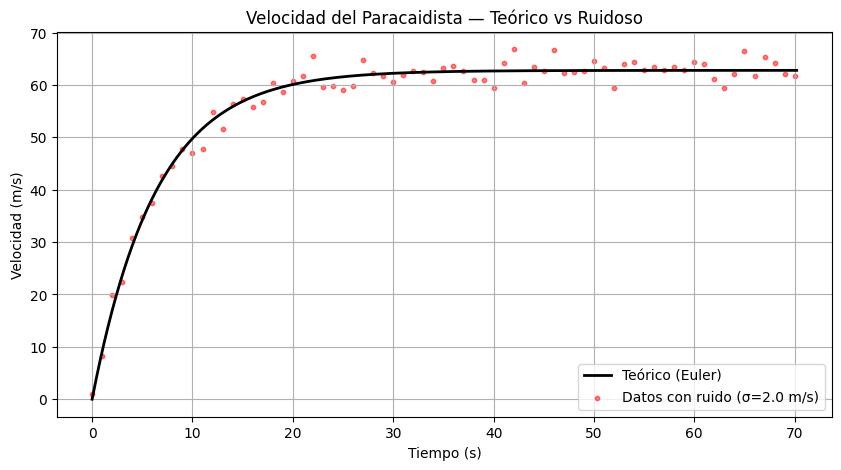

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import time

# ── Parámetros físicos ──────────────────────────────────────────
m   = 80.0    # masa (kg)
g   = 9.81    # gravedad (m/s²)
k   = 12.5    # coeficiente de arrastre (kg/s)
h0  = 4000.0  # altura inicial (m)
dt  = 0.1

# ── Método de Euler ─────────────────────────────────────────────
t_list, v_list, x_list = [0.0], [0.0], [h0]
while x_list[-1] > 0:
    v_list.append(v_list[-1] + dt * (g - (k/m)*v_list[-1]))
    x_list.append(x_list[-1] - dt * v_list[-2])
    t_list.append(t_list[-1] + dt)

t = np.array(t_list)
v = np.array(v_list)
x = np.array(x_list)

print(f"Tiempo de impacto : {t[-1]:.2f} s")
print(f"Velocidad final   : {v[-1]:.2f} m/s")

# ── Agregar ruido gaussiano ──────────────────────────────────────
RUIDO_STD = 2.0          # desviación estándar del ruido (m/s)
np.random.seed(42)
v_ruidoso = v + np.random.normal(0, RUIDO_STD, size=v.shape)

# ── Guardar datos ruidosos en .dat ───────────────────────────────
nombre_dat = f"paracaidista_ruido_std{RUIDO_STD:.1f}.dat"
with open(nombre_dat, "w") as f:
    f.write(f"{'Tiempo (s)':>15} {'Velocidad_real (m/s)':>22} {'Velocidad_ruido (m/s)':>23}\n")
    for ti, vi, vri in zip(t, v, v_ruidoso):
        f.write(f"{ti:15.5f} {vi:22.8f} {vri:23.8f}\n")
print(f"Datos guardados en: {nombre_dat}")

# ── Gráfica teórico vs ruidoso ───────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(t, v, label='Teórico (Euler)', color='black', linewidth=2)

# Muestreo para reducir la cantidad de puntos en la gráfica de dispersión
sample_interval = 10 # Tomar un punto cada 10 puntos
plt.scatter(t[::sample_interval], v_ruidoso[::sample_interval], label=f'Datos con ruido (σ={RUIDO_STD} m/s)',
            color='red', s=10, alpha=0.5)
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad (m/s)')
plt.title('Velocidad del Paracaidista — Teórico vs Ruidoso')
plt.legend()
plt.grid()
plt.show()

## 2. Preparación de datos y Red Neuronal Profunda (DNN)

In [ ]:
# ── Escalado para la DNN ─────────────────────────────────────────
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X = t.reshape(-1, 1)
y = v_ruidoso.reshape(-1, 1)

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

# ── Arquitectura: 4 capas ocultas (Grande) ───────────────────────
dnn = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(1,)),
    layers.Dense(64,  activation='relu'),
    layers.Dense(32,  activation='relu'),
    layers.Dense(16,  activation='relu'),
    layers.Dense(1)
])
dnn.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
            loss='mse', metrics=['mae'])

print("Entrenando DNN...")
t0 = time.time()
hist_dnn = dnn.fit(
    X_train, y_train,
    epochs=500,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=0
)
tiempo_dnn = time.time() - t0
print(f"DNN lista en {tiempo_dnn:.2f} s  |  val_loss final: {hist_dnn.history['val_loss'][-1]:.6f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entrenando DNN...


## 3. PINN (Physics-Informed Neural Network)

In [ ]:
class PINN(keras.Model):
    def __init__(self, model_core, m, g, k, t_cero,
                 lambda_fisica=1.0, lambda_ic=1.0, lambda_data=1.0,
                 adapt_weights=True, **kwargs):
        super().__init__(**kwargs)

        self.model_core = model_core
        self.m = tf.constant(m, dtype=tf.float32)
        self.g = tf.constant(g, dtype=tf.float32)
        self.k = tf.constant(k, dtype=tf.float32)

        self.t_cero = t_cero

        # Pesos iniciales
        self.lambda_fisica = tf.Variable(lambda_fisica, trainable=False)
        self.lambda_ic     = tf.Variable(lambda_ic, trainable=False)
        self.lambda_data   = tf.Variable(lambda_data, trainable=False)

        self.adapt_weights = adapt_weights

        # Métricas
        self.loss_tracker    = keras.metrics.Mean(name='loss')
        self.data_loss_tr    = keras.metrics.Mean(name='data_loss')
        self.physics_loss_tr = keras.metrics.Mean(name='physics_loss')
        self.ic_loss_tr      = keras.metrics.Mean(name='ic_loss')

    def call(self, inputs):
        return self.model_core(inputs)

    @tf.function
    def train_step(self, data):
        t_batch, v_batch = data

        with tf.GradientTape() as tape:
            with tf.GradientTape() as tape_f:
                tape_f.watch(t_batch)
                v_pred = self.model_core(t_batch)

            dv_dt = tape_f.gradient(v_pred, t_batch)

            # --- PÉRDIDAS ---
            residuo = dv_dt - self.g + (self.k / self.m) * v_pred
            physics_loss = tf.reduce_mean(tf.square(residuo))

            data_loss = tf.reduce_mean(tf.square(v_batch - v_pred))

            v_en_cero = self.model_core(self.t_cero)
            ic_loss = tf.reduce_mean(tf.square(v_en_cero))

            # --- AJUSTE DINÁMICO ---
            if self.adapt_weights:
                total = physics_loss + data_loss + ic_loss + 1e-8

                self.lambda_fisica.assign(total / (physics_loss + 1e-8))
                self.lambda_data.assign(total / (data_loss + 1e-8))
                self.lambda_ic.assign(total / (ic_loss + 1e-8))

            # --- LOSS TOTAL ---
            total_loss = (
                self.lambda_data * data_loss +
                self.lambda_fisica * physics_loss +
                self.lambda_ic * ic_loss
            )

        grads = tape.gradient(total_loss, self.model_core.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.model_core.trainable_variables))

        # Métricas
        self.loss_tracker.update_state(total_loss)
        self.data_loss_tr.update_state(data_loss)
        self.physics_loss_tr.update_state(physics_loss)
        self.ic_loss_tr.update_state(ic_loss)

        return {
            'loss': total_loss,
            'data_loss': data_loss,
            'physics_loss': physics_loss,
            'ic_loss': ic_loss,
            'λ_data': self.lambda_data,
            'λ_fisica': self.lambda_fisica,
            'λ_ic': self.lambda_ic
        }

## 4. Comparativa visual: DNN vs PINN

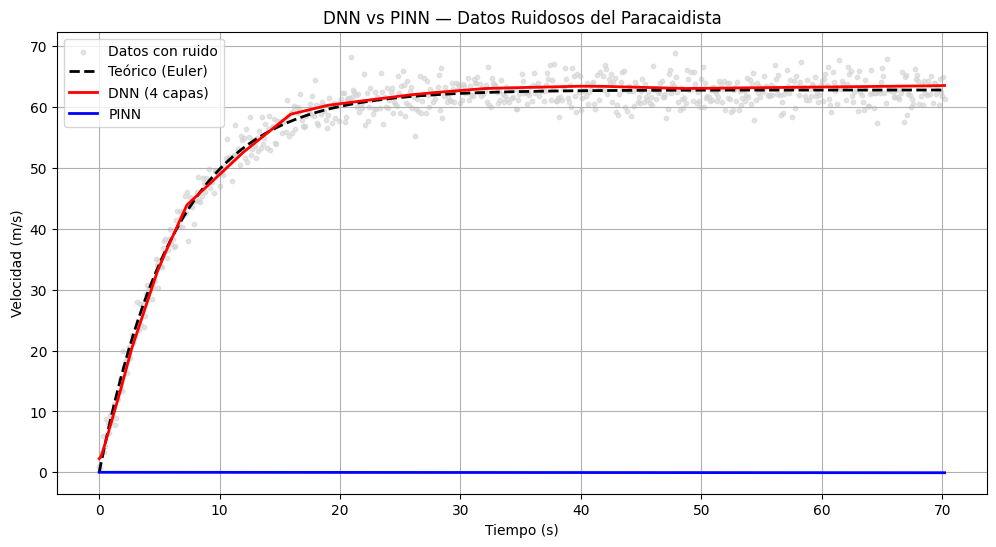

In [13]:
# ── Predicciones ────────────────────────────────────────────────
v_pred_dnn  = scaler_y.inverse_transform(dnn.predict(X_scaled, verbose=0))
v_pred_pinn = pinn.predict(T_tensor, verbose=0)

# ── Gráfica principal ────────────────────────────────────────────
plt.figure(figsize=(12, 6))
plt.scatter(t, v_ruidoso, color='lightgray', s=10, alpha=0.6, label='Datos con ruido')
plt.plot(t, v,             color='black',  linewidth=2, linestyle='--', label='Teórico (Euler)')
plt.plot(t, v_pred_dnn,    color='red',    linewidth=2, label='DNN (4 capas)')
plt.plot(t, v_pred_pinn,   color='blue',   linewidth=2, label='PINN')
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad (m/s)')
plt.title('DNN vs PINN — Datos Ruidosos del Paracaidista')
plt.legend()
plt.grid(True)
plt.show()

## 5. Curvas de pérdida durante el entrenamiento

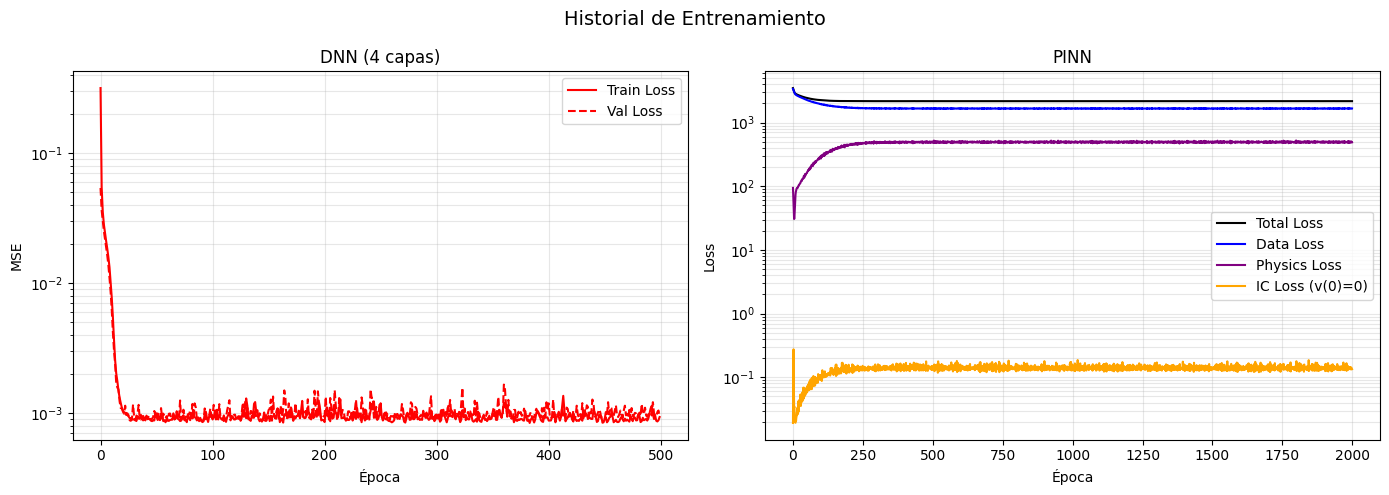

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Historial de Entrenamiento', fontsize=14)

# DNN
axes[0].plot(hist_dnn.history['loss'],     label='Train Loss', color='red')
axes[0].plot(hist_dnn.history['val_loss'], label='Val Loss',   color='red', linestyle='--')
axes[0].set_title('DNN (4 capas)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('MSE')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(True, which='both', alpha=0.3)

# PINN
axes[1].plot(hist_pinn.history['loss'],         label='Total Loss',      color='black')
axes[1].plot(hist_pinn.history['data_loss'],    label='Data Loss',       color='blue')
axes[1].plot(hist_pinn.history['physics_loss'], label='Physics Loss',    color='purple')
axes[1].plot(hist_pinn.history['ic_loss'],      label='IC Loss (v(0)=0)',color='orange')
axes[1].set_title('PINN')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Métricas de error y resumen

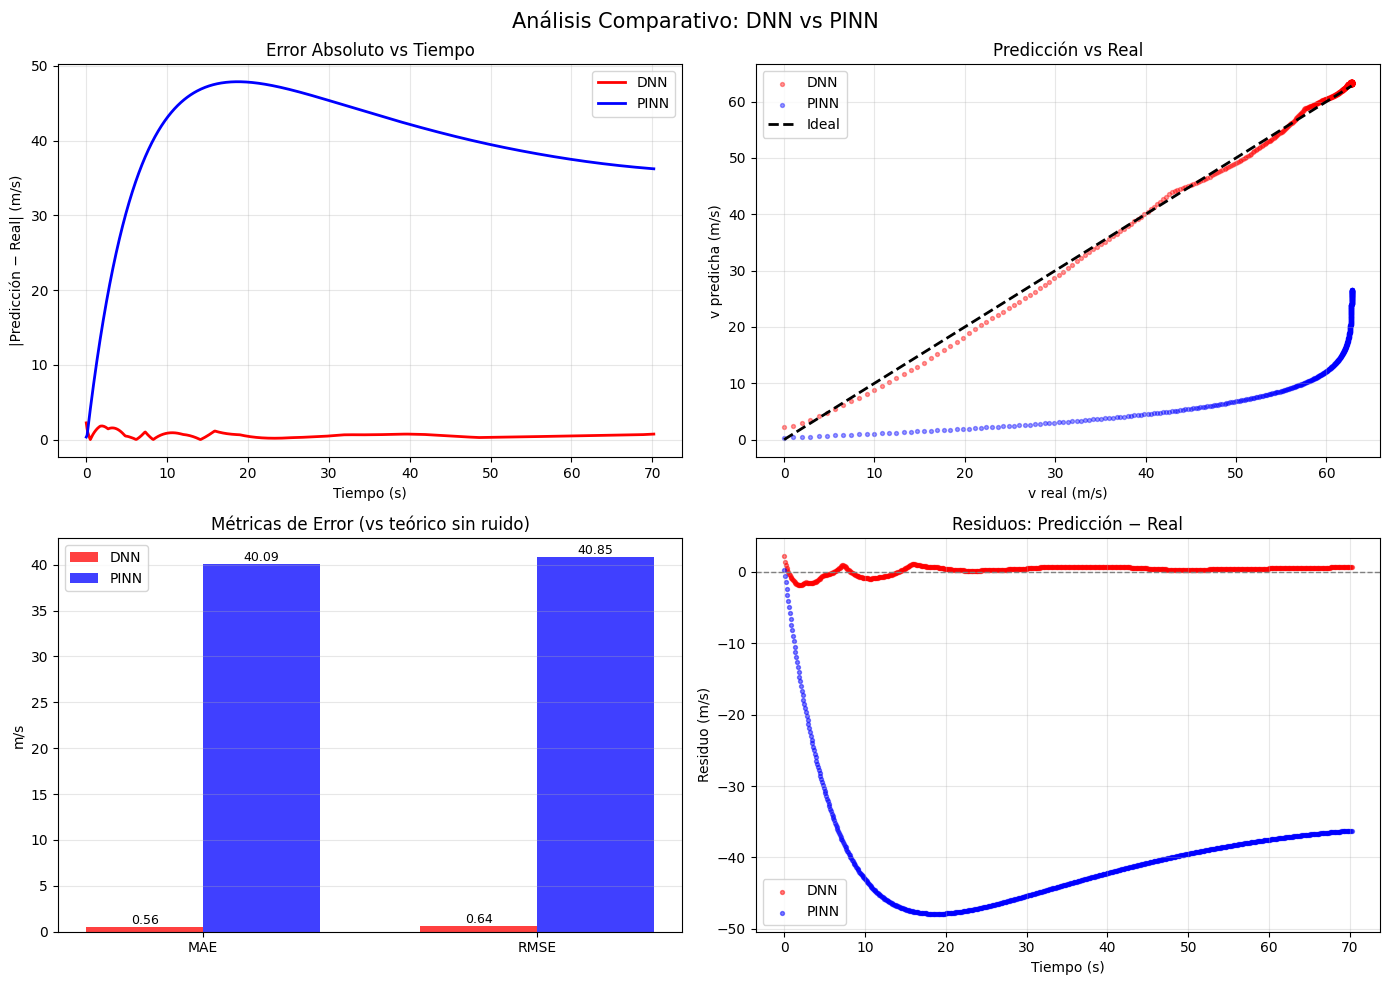

RESUMEN: DNN vs PINN
Métrica                     DNN       PINN
-------------------------------------------------------
MAE  (m/s)               0.5639    40.0861
RMSE (m/s)               0.6403    40.8504
Error máx (m/s)          2.2419    47.8952
Tiempo entreno (s)        88.97     174.06
Mejora PINN sobre DNN — MAE : -7008.86%
Mejora PINN sobre DNN — RMSE: -6280.28%


In [7]:
# ── Calcular errores respecto a la solución TEÓRICA (sin ruido) ──
err_dnn  = np.abs(v_pred_dnn.flatten()  - v)
err_pinn = np.abs(v_pred_pinn.flatten() - v)

mae_dnn   = np.mean(err_dnn)
mae_pinn  = np.mean(err_pinn)
rmse_dnn  = np.sqrt(np.mean(err_dnn**2))
rmse_pinn = np.sqrt(np.mean(err_pinn**2))

# ── Panel de 4 gráficas ──────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análisis Comparativo: DNN vs PINN', fontsize=15)

# 1. Error absoluto vs tiempo
ax = axes[0, 0]
ax.plot(t, err_dnn,  color='red',  linewidth=2, label='DNN')
ax.plot(t, err_pinn, color='blue', linewidth=2, label='PINN')
ax.set_title('Error Absoluto vs Tiempo')
ax.set_xlabel('Tiempo (s)')
ax.set_ylabel('|Predicción − Real| (m/s)')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Scatter predicción vs real
ax = axes[0, 1]
ax.scatter(v, v_pred_dnn.flatten(),  color='red',  s=8, alpha=0.4, label='DNN')
ax.scatter(v, v_pred_pinn.flatten(), color='blue', s=8, alpha=0.4, label='PINN')
lim = [v.min(), v.max()]
ax.plot(lim, lim, 'k--', linewidth=2, label='Ideal')
ax.set_title('Predicción vs Real')
ax.set_xlabel('v real (m/s)')
ax.set_ylabel('v predicha (m/s)')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Barras MAE y RMSE
ax = axes[1, 0]
metricas = ['MAE', 'RMSE']
vals_dnn  = [mae_dnn,  rmse_dnn]
vals_pinn = [mae_pinn, rmse_pinn]
xp = np.arange(2)
w  = 0.35
b1 = ax.bar(xp - w/2, vals_dnn,  w, label='DNN',  color='red',  alpha=0.75)
b2 = ax.bar(xp + w/2, vals_pinn, w, label='PINN', color='blue', alpha=0.75)
for barras in [b1, b2]:
    for barra in barras:
        h = barra.get_height()
        ax.text(barra.get_x() + barra.get_width()/2, h,
                f'{h:.2f}', ha='center', va='bottom', fontsize=9)
ax.set_title('Métricas de Error (vs teórico sin ruido)')
ax.set_xticks(xp)
ax.set_xticklabels(metricas)
ax.set_ylabel('m/s')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

# 4. Residuos
ax = axes[1, 1]
ax.scatter(t, v_pred_dnn.flatten()  - v, color='red',  s=8, alpha=0.5, label='DNN')
ax.scatter(t, v_pred_pinn.flatten() - v, color='blue', s=8, alpha=0.5, label='PINN')
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Residuos: Predicción − Real')
ax.set_xlabel('Tiempo (s)')
ax.set_ylabel('Residuo (m/s)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Resumen numérico ─────────────────────────────────────────────
print('=' * 55)
print('RESUMEN: DNN vs PINN')
print('=' * 55)
print(f"{'Métrica':<20} {'DNN':>10} {'PINN':>10}")
print('-' * 55)
print(f"{'MAE  (m/s)':<20} {mae_dnn:>10.4f} {mae_pinn:>10.4f}")
print(f"{'RMSE (m/s)':<20} {rmse_dnn:>10.4f} {rmse_pinn:>10.4f}")
print(f"{'Error máx (m/s)':<20} {np.max(err_dnn):>10.4f} {np.max(err_pinn):>10.4f}")
print(f"{'Tiempo entreno (s)':<20} {tiempo_dnn:>10.2f} {tiempo_pinn:>10.2f}")
print('=' * 55)
mejora_mae  = (mae_dnn  - mae_pinn)  / mae_dnn  * 100
mejora_rmse = (rmse_dnn - rmse_pinn) / rmse_dnn * 100
print(f"Mejora PINN sobre DNN — MAE : {mejora_mae:+.2f}%")
print(f"Mejora PINN sobre DNN — RMSE: {mejora_rmse:+.2f}%")